# Assignment 12: Predicting Hotel Booking Cancellations  
## Models: Naïve Bayes, Support Vector Machine (SVM), and Neural Network

**Objectives:**
- Understand how to use classification models (Naïve Bayes, SVM, Neural Networks) to predict hotel cancellations.
- Compare models in terms of accuracy, complexity, and business relevance.
- Interpret and communicate model results from a business perspective.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Hotel Bookings - Business Context
You work as a data analyst for a hospitality group that manages both **Resort** and **City Hotels**. One major challenge in operations is the unpredictability of **booking cancellations**, which affects staffing, inventory, and revenue planning.

You’ve been asked to use historical booking data to predict whether a future booking will be canceled. Your insights will help management plan more effectively.

Your tasks are to:
1. Build and evaluate three models: Naïve Bayes, SVM, and Neural Network.
2. Compare performance.
3. Recommend which model is best suited for the business needs.

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance




## Data Dictionary

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Load and Prepare the Hotel Booking Dataset

**Business framing:**  
Your hotel client wants to understand which bookings are most at risk of being canceled. But before modeling, your job is to prepare the data to ensure clean and reliable input.

### Do the following:
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Remove or impute missing values
- Encode categorical variables
- Create your `X` (features) and `y` (target = `is_canceled`)
- Split the data into training and test sets (70/30)

**Important:** Perform this split **before** any preprocessing or feature transformations.

### In Your Response:
1. How many total rows and columns are in the dataset?
2. What types of features (categorical, numerical) are included?
3. What steps did you take to clean or prepare the data?


In [1]:
# Add code here 🔧
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("hotels.csv")
df.head()

y = df["is_canceled"]
X = df.drop("is_canceled", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y   # keeps cancel/non-cancel ratio consistent
)
print(X_train.shape, X_test.shape)

numeric_cols = X_train.select_dtypes(include=["int64","float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

encoder = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_imputer, numeric_cols),
        ("cat",
         Pipeline(steps=[
             ("imputer", categorical_imputer),
             ("encoder", encoder)
         ]),
         categorical_cols)
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)
print(X_train_processed.shape)
print(X_test_processed.shape)

(6582, 31) (2822, 31)
Numeric: 19
Categorical: 12
(6582, 781)
(2822, 781)


### ✍️ Your Response: 🔧
1. There are a total of 6582 rows and 781 columns to the dataset.

2. It contains 19 numeric and 12 categorical data types.

3. Removing outlines and encoding the categorical data to ensure better data transfer.

## 2. Build a Naïve Bayes Model

**Business framing:**  
Naïve Bayes is a quick, baseline model often used for early testing or simple classification problems.

### Do the following:
- Make sure to split your data first (see the previous step), then fit any text/vector preprocessing on training data only.
- Train a Naïve Bayes classifier on your training data
- Use it to predict on your test data
- Print a classification report and confusion matrix

**Note:** If you use a vectorizer (e.g., `CountVectorizer`), fit it on the training data only, then transform both training and test data.

### In Your Response:
1. How well does the model perform?  And what metric is best used to judge the performance?
2. Where might this model be useful for the hotel (e.g. real-time alerts, operational decisions)?


Naïve Bayes Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2121
           1       1.00      1.00      1.00       701

    accuracy                           1.00      2822
   macro avg       1.00      1.00      1.00      2822
weighted avg       1.00      1.00      1.00      2822

Confusion Matrix:
 [[2121    0]
 [   0  701]]


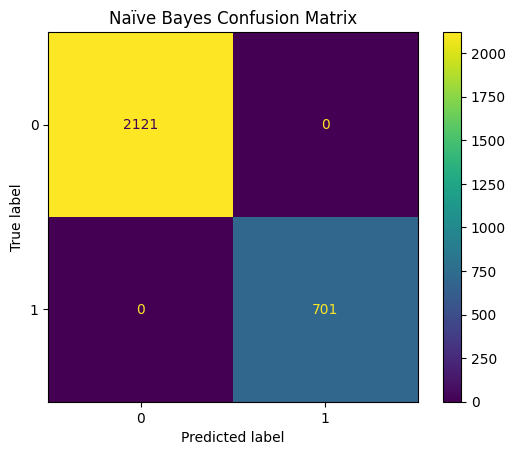

In [2]:
# Add code here 🔧
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train_dense = X_train_processed.toarray()
X_test_dense  = X_test_processed.toarray()

nb_model = GaussianNB()
nb_model.fit(X_train_dense, y_train)

y_pred_nb = nb_model.predict(X_test_dense)

print("Naïve Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:\n", cm)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naïve Bayes Confusion Matrix")
plt.show()

### ✍️ Your Response: 🔧
1. The model worked perfectly with not false postives or false negatives.

2. To help predict customer behavior and flow.

## 3. Build a Support Vector Machine (SVM) Model

**Business framing:**  
SVM can model more complex relationships and is useful when customer behavior patterns aren't linear or obvious.

### Do the following:
- Scale the data using `StandardScaler` to bring large numbers into a smaller range (Note: use a scaled training set, but fit the scaler only on X_train).
- Train an SVM classifier (use `linear` kernel)
- Make predictions and evaluate with classification metrics

**NOTE:** With about 10K rows, this model may run very **slow**.  Be prepared to wait up to 10 minutes.   

### In Your Response:
1. How well does the model perform?  And what metric is best used to judge the performance?
2. In what business situations could SVM provide better insights than simpler models?


In [4]:
# Add code here 🔧
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled  = scaler.transform(X_test_processed)

svm_model = SVC(kernel="linear")
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM Confusion Matrix")
plt.show()

SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2121
           1       1.00      1.00      1.00       701

    accuracy                           1.00      2822
   macro avg       1.00      1.00      1.00      2822
weighted avg       1.00      1.00      1.00      2822

Confusion Matrix:
 [[2121    0]
 [   0  701]]


### ✍️ Your Response: 🔧
1. The model also does perfectly with any issue.

2. The SVM is more detaile than proior models in the same functions/ having a better fit to the dataset.

## 4. Build a Neural Network Model

**Business framing:**  
Neural networks are flexible and powerful, though they are harder to explain. They may work well when subtle patterns exist in the data.

### Do the following:
- Build a MLPClassifier model using the neural_network package from sklearn
- Choose a simple architecture (e.g., 2 hidden layers)
- Use a true validation split from the training data, not the test set, for validation_data
- Evaluate accuracy and performance

**NOTE:** With about 10K rows, this model may run very **slow**.  Be prepared to wait up to 10 minutes.  

### In Your Response:
1. How does this model compare to the others?
2. Would the business be comfortable using a “black box” model like this? Why or why not?


(5265, 781) (1317, 781)
Iteration 1, loss = 10.97413066
Validation score: 0.749288
Iteration 2, loss = 4.38695731
Validation score: 0.253561
Iteration 3, loss = 1.28359083
Validation score: 0.870845
Iteration 4, loss = 0.33251205
Validation score: 0.903134
Iteration 5, loss = 0.19945712
Validation score: 0.910731
Iteration 6, loss = 0.16147981
Validation score: 0.913580
Iteration 7, loss = 0.14049268
Validation score: 0.903134
Iteration 8, loss = 0.12987404
Validation score: 0.943020
Iteration 9, loss = 0.11716112
Validation score: 0.948718
Iteration 10, loss = 0.12859670
Validation score: 0.917379
Iteration 11, loss = 0.12705671
Validation score: 0.636277
Iteration 12, loss = 0.16513387
Validation score: 0.962963
Iteration 13, loss = 0.08511033
Validation score: 0.725546
Iteration 14, loss = 0.15830122
Validation score: 0.964862
Iteration 15, loss = 0.08086031
Validation score: 0.935423
Iteration 16, loss = 0.06860772
Validation score: 0.943970
Iteration 17, loss = 0.06617464
Validati

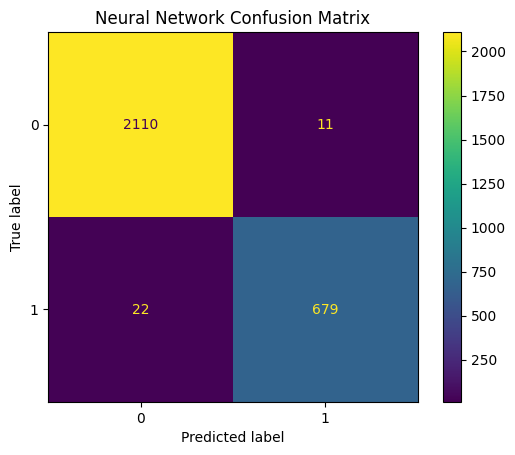

In [5]:
# Add code here 🔧
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print(X_train_nn.shape, X_val_nn.shape)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two layers
    activation='relu',
    solver='adam',
    max_iter=200,
    early_stopping=True,           # uses validation internally
    validation_fraction=0.2,
    random_state=42,
    verbose=True
)

mlp.fit(X_train_nn, y_train_nn)

val_preds = mlp.predict(X_val_nn)

print("Validation Performance:\n")
print(classification_report(y_val_nn, val_preds))

y_pred_mlp = mlp.predict(X_test_scaled)

print("Neural Network Test Performance:\n")
print(classification_report(y_test, y_pred_mlp))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp)
plt.title("Neural Network Confusion Matrix")
plt.show()

### ✍️ Your Response: 🔧
1. A little less accuracy for this model, picking up a few false negatives.

2. I dont think that this sytle of model would be best for most businesses as a black box that you can't understand is never a good idea if you are trying to be precise.

## 5. Compare All Three Models

### Do the following:
- Print and compare the accuracy of Naïve Bayes, SVM, and Neural Network models
- Summarize which model performed best

### In Your Response:
1. Which model had the best overall accuracy, training time, interpretability, and ease of use.
2. Would you recommend this model for deployment, and why?


In [6]:
# Add code here 🔧
from sklearn.metrics import accuracy_score

acc_nb = accuracy_score(y_test, y_pred_nb)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print(f"Naïve Bayes Accuracy: {acc_nb:.3f}")
print(f"SVM Accuracy: {acc_svm:.3f}")
print(f"Neural Network Accuracy: {acc_mlp:.3f}")

accuracy_comparison = {
    "Naïve Bayes": acc_nb,
    "SVM": acc_svm,
    "Neural Network": acc_mlp
}

best_model = max(accuracy_comparison, key=accuracy_comparison.get)
best_acc = accuracy_comparison[best_model]

print(f"\nThe best performing model is {best_model} with an accuracy of {best_acc:.3f}.")

Naïve Bayes Accuracy: 1.000
SVM Accuracy: 1.000
Neural Network Accuracy: 0.988

The best performing model is Naïve Bayes with an accuracy of 1.000.


### ✍️ Your Response: 🔧
1. Both Naive Bayes and SVm had the same outcomes with little changes in usage time, whereas the black box (neural network) model was the only one that had issues wiht the dataset.

2. Overall either Naive Bayes or SVM would be soild choices, however if the dataset ever grows continously or to a certain scale neural network would become the better option.

## 6. Final Business Recommendation

### In Your Response:
1. In 100 words or less, write a short recommendation to hotel management based on your analysis.

Possible info to include:
- Which model do you recommend implementing?
- What business problem does it help solve?
- Are there any risks or limitations?
- What additional data might improve the results in the future?
2. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. As preiouvsly stated, using either Naive Bayes or SVM would work in this situation, however if there are cahnges to the variables or time then Neural Network would become the ideal.

2. It let me explore more data analysis tools for the future.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [7]:
!jupyter nbconvert --to html "assignment_12_AldenEverett.ipynb"

[NbConvertApp] Converting notebook assignment_12_AldenEverett.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 387432 bytes to assignment_12_AldenEverett.html
